# LAB 03 - EDA & TIEN XU LY
## House Prices: Advanced Regression Techniques (Ames Housing)

**Thanh vien 1 - phan trach:** Phan tich du lieu, xu ly missing values, xay dung preprocessing pipeline dung chung cho ca nhom.

### Muc tieu cua notebook nay

1. Xac dinh bai toan va metric danh gia.
2. Kiem tra shape, kieu du lieu, missing values cua `train.csv` va `test.csv`.
3. Phan tich target `SalePrice` va ly do phai bien doi `log1p`.
4. Phan tich dac trung so va categorical.
5. Phan tich tuong quan, phat hien outlier.
6. Xay dung `preprocessing pipeline` de thieu vien 2 va 3 dung chung.

> **Quy tac quan trong (plan muc 16):** khong danh gia tren `test.csv` vi file nay khong co `SalePrice`. Moi danh gia deu dung cross-validation hoac tach train/validation. Khong fit scaler/imputer/encoder tren toan bo du lieu truoc khi chia tap, neu khong se ro ri thong tin (data leakage).

## 1. Cau hinh chung va nap du lieu

Dung `random seed = 42` cho toan bo nhom theo quy dinh plan muc 16. Ma nguon dung chung nam trong `src/preprocessing.py`.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Kiem tra dang chay tu dau notebook hay tu giua chung
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "train.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

FIG_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("data/        :", (PROJECT_ROOT / "data").exists())
print("src/         :", SRC_DIR.exists())
print("figures/     :", FIG_DIR.exists())

PROJECT_ROOT : /home/hungmg/Documents/python/GROUP_DEEEP_LEARNING_HK1_2026/TUAN03/lab03_house_price
data/        : True
src/         : True
figures/     : True


In [2]:
import preprocessing as pp

train, test = pp.load_data(PROJECT_ROOT / "data")

print("train:", train.shape)
print("test :", test.shape)
print("Target co trong train:", pp.TARGET_COLUMN in train.columns)
print("Target co trong test :", pp.TARGET_COLUMN in test.columns)

train: (1460, 81)
test : (1459, 80)
Target co trong train: True
Target co trong test : False


## 2. Xac dinh bai toan

Day la bai toan **Supervised Learning - Regression**:

- **Input X:** tap dac trung mo ta can nha.
- **Target y:** `SalePrice` — gia ban cua can nha.
- **Metric:** RMSE tren `log1p(SalePrice)`.

Ve sao dung `log1p`? Phan tich o muc 5 se giai thich bang so lieu.

In [3]:
print("So mau train:", len(train))
print("So mau test :", len(test))
print("Tong so cot train:", train.shape[1])
print("Tong so cot test :", test.shape[1])
print("Cot chi co o train:", [c for c in train.columns if c not in test.columns])
print("Cot chi co o test :", [c for c in test.columns if c not in train.columns])

So mau train: 1460
So mau test : 1459
Tong so cot train: 81
Tong so cot test : 80
Cot chi co o train: ['SalePrice']
Cot chi co o test : []


## 3. Kiem tra kieu du lieu

Chia cot thanh 3 nhom: so nguyen (int64), so thuc (float64), chuoi (object).

In [4]:
print("=== 5 dong dau ===")
display(train.head())

print("=== 5 dong cuoi ===")
display(train.tail())

=== 5 dong dau ===


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


=== 5 dong cuoi ===


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [6]:
print("So cot theo kieu du lieu:")
display(train.dtypes.value_counts())

int_cols = train.select_dtypes("int64").columns.tolist()
float_cols = train.select_dtypes("float64").columns.tolist()
object_cols = train.select_dtypes(include=pp.STRING_DTYPES).columns.tolist()

print(f"int64   ({len(int_cols)}):", int_cols)

print(f"float64 ({len(float_cols)}):", float_cols)

print(f"object  ({len(object_cols)}):", object_cols)

So cot theo kieu du lieu:


str        43
int64      35
float64     3
Name: count, dtype: int64

int64   (35): ['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
float64 (3): ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']
object  (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'Firepla

## 4. Kiem tra missing values

Day la buoc quan trong nhat cua phan EDA. Ames Housing co **nhieu cot thieu du lieu**, va phan lon trong do la co chu dich: nhung cot sau khong ton tai khi nha khong co tinh nang do.

In [7]:
train_missing = train.isnull().sum()
train_missing = train_missing[train_missing > 0].sort_values(ascending=False)

print(f"So cot bi thieu du lieu: {len(train_missing)}")
print(f"Tong so o gia tri thieu: {int(train_missing.sum())}")
print(f"Ty le gia tri thieu: {train.isnull().mean().mean() * 100:.2f}%")

display(pd.DataFrame({
    "so_o_thieu": train_missing,
    "ty_le": (train_missing / len(train) * 100).round(2),
}))

So cot bi thieu du lieu: 19
Tong so o gia tri thieu: 7829
Ty le gia tri thieu: 6.62%


,so_o_thieu,ty_le
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


### 4.1. Doc y nghia missing value

| Nhom cot | Y nghia | So cot |
|---|---|---:|
| `PoolQC`, `MiscFeature`, `Alley`, `Fence` | Nha khong co ho boi / tien ich / nghia / hao rao | 4 |
| `FireplaceQu`, `Garage*`, `Bsmt*`, `MasVnrType` | Nha khong co lo do / ga xe / tang hoam / lat op | 14 |
| `LotFrontage` | Khong ghi duong tiep canh | 1 |
| `Electrical` | Thieu 1 mau | 1 |

Nhin chung: **missing o day phan lon la "khong co vat th" chu khong phai "lo du lieu"**.

> **Quyet dinh xu ly:** dung `SimpleImputer` thay vì xoa dong hay cot.
> - Numeric: dien **median** — it anh huong den phan phoi lech.
> - Categorical: dien **gia tri pho bien nhat** (most_frequent).
> - Khong xoa dong nao: chi 7829 o tren tong so o du lieu (6.5%), va xoa dong se lam mat mau cho truong hop "khong co tinh nang" la thong tin quan trong.

In [8]:
miss_train = train.isnull().mean()
miss_test = test.isnull().mean()
miss_cmp = pd.DataFrame({"train": miss_train, "test": miss_test})
miss_cmp["chenh_lech"] = (miss_cmp["train"] - miss_cmp["test"]).abs()
miss_cmp = miss_cmp[miss_cmp[["train", "test"]].sum(axis=1) > 0]
miss_cmp = miss_cmp.sort_values("chenh_lech", ascending=False)

print("=== 8 cot co chenh lech ty le missing lon nhat giua train va test ===")
display(miss_cmp.head(8).round(4))

print(f"Dong co chenh lech > 5%: {(miss_cmp['chenh_lech'] > 0.05).sum()}")
print("-> train va test phan bo missing tuong doi giong nhau.")

=== 8 cot co chenh lech ty le missing lon nhat giua train va test ===


,train,test,chenh_lech
FireplaceQu,0.4726,0.5003,0.0277
LotFrontage,0.1774,0.1556,0.0218
MasVnrType,0.5973,0.6127,0.0155
Alley,0.9377,0.9267,0.0110
Fence,0.8075,0.8012,0.0063
BsmtCond,0.0253,0.0308,0.0055
BsmtQual,0.0253,0.0302,0.0048
MasVnrArea,0.0055,0.0103,0.0048


Dong co chenh lech > 5%: 0
-> train va test phan bo missing tuong doi giong nhau.


## 5. Phan tich target `SalePrice`

### 5.1. Thong ke mo ta

In [9]:
saleprice = train[pp.TARGET_COLUMN]

print(f"Min     : {saleprice.min():,.0f}")
print(f"Max     : {saleprice.max():,.0f}")
print(f"Mean    : {saleprice.mean():,.0f}")
print(f"Median  : {saleprice.median():,.0f}")
print(f"Std     : {saleprice.std():,.0f}")
print(f"Skew    : {saleprice.skew():.4f}")
print(f"Kurtosis: {saleprice.kurtosis():.4f}")

print()
print("Muc do lech phai cua SalePrice:")
print("  -> skew > 1 : PHAN PHOI LECH PHAI MANH" if saleprice.skew() > 1 else "  -> phan phoi gan doi xung")

Min     : 34,900
Max     : 755,000
Mean    : 180,921
Median  : 163,000
Std     : 79,443
Skew    : 1.8829
Kurtosis: 6.5363

Muc do lech phai cua SalePrice:
  -> skew > 1 : PHAN PHOI LECH PHAI MANH


### 5.2. Vi sao phai dung `log1p(SalePrice)`?

`SalePrice` lech phai manh (skew > 1): phan lon nha re, it nha dat. Bien doi log se:

1. Lam phan phoi gan doi xung hon — phu hop voi gia don bien va Ridge.
2. Giam anh huong cua vai duoi (outlier) khoi mo hinh.

Dung `log1p` (log cua `1 + x`) thay vi `log` de giu nguyen gia tri 0 neu co.

### 5.3. Bieu do phan phoi SalePrice va log1p(SalePrice)

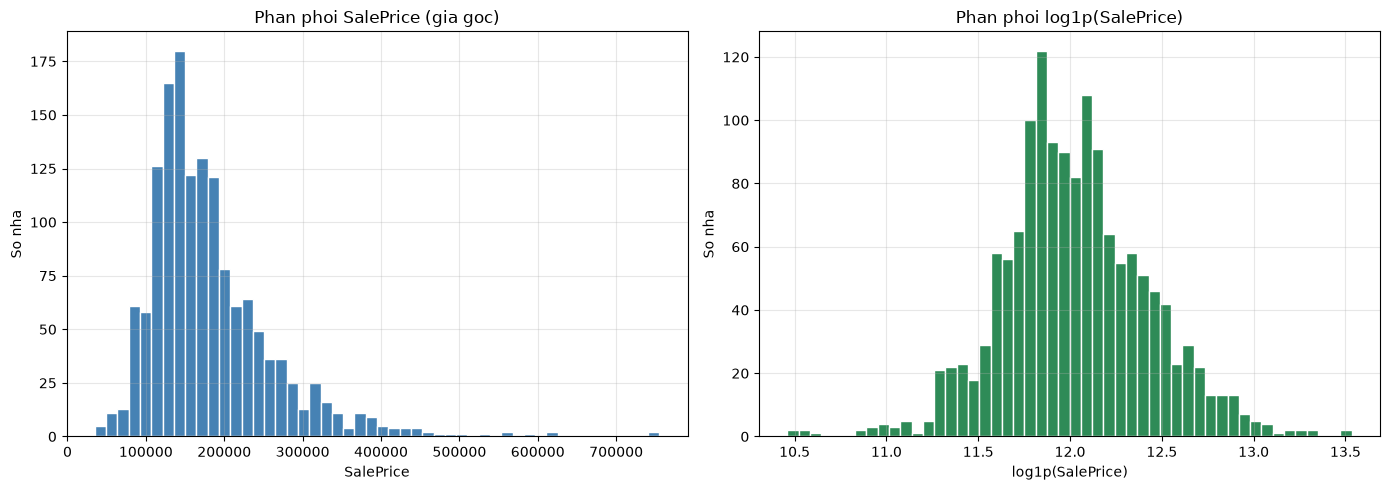

Skewness SalePrice       : 1.8829
Skewness log1p(SalePrice): 0.1213
-> Skew giam manh sau bien doi log => phan phoi gan doi xung hon.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(saleprice, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Phan phoi SalePrice (gia goc)")
axes[0].set_xlabel("SalePrice")
axes[0].set_ylabel("So nha")

log_price = np.log1p(saleprice)
axes[1].hist(log_price, bins=50, color="seagreen", edgecolor="white")
axes[1].set_title("Phan phoi log1p(SalePrice)")
axes[1].set_xlabel("log1p(SalePrice)")
axes[1].set_ylabel("So nha")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "saleprice_distribution.png", dpi=150)
plt.show()

print(f"Skewness SalePrice       : {saleprice.skew():.4f}")
print(f"Skewness log1p(SalePrice): {log_price.skew():.4f}")
print("-> Skew giam manh sau bien doi log => phan phoi gan doi xung hon.")

## 6. Phan tich dac trung so (numerical features)

### 6.1. Thong ke mo ta cac dac trung so chinh

In [11]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
print(f"So dac trung so: {len(numeric_cols)}")

main_features = ["OverallQual", "GrLivArea", "GarageArea", "TotalBsmtSF",
                  "1stFlrSF", "FullBath", "YearBuilt", "YearRemodAdd",
                  "TotRmsAbvGrd", "Fireplaces", "LotFrontage", "LotArea"]

display(train[main_features].describe().T.round(2))

So dac trung so: 38


,count,mean,std,min,25%,50%,75%,max
OverallQual,1460.0,6.10,1.38,1.0,5.00,6.0,7.00,10.0
GrLivArea,1460.0,1515.46,525.48,334.0,1129.50,1464.0,1776.75,5642.0
GarageArea,1460.0,472.98,213.80,0.0,334.50,480.0,576.00,1418.0
TotalBsmtSF,1460.0,1057.43,438.71,0.0,795.75,991.5,1298.25,6110.0
1stFlrSF,1460.0,1162.63,386.59,334.0,882.00,1087.0,1391.25,4692.0
FullBath,1460.0,1.57,0.55,0.0,1.00,2.0,2.00,3.0
YearBuilt,1460.0,1971.27,30.20,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.87,20.65,1950.0,1967.00,1994.0,2004.00,2010.0
TotRmsAbvGrd,1460.0,6.52,1.63,2.0,5.00,6.0,7.00,14.0
Fireplaces,1460.0,0.61,0.64,0.0,0.00,1.0,1.00,3.0


### 6.2. Tuong quan cua dac trung so voi SalePrice

Tinh tuong quan voi `log1p(SalePrice)` vi day la target se train.

In [12]:
corr_with_target = pd.Series(
    {col: np.corrcoef(train[col], log_price)[0, 1]
     for col in numeric_cols if col != "Id"}
)
corr_with_target = corr_with_target.dropna().sort_values(key=abs, ascending=False)

print("=== 15 dac trung so tuong quan manh nhat voi log1p(SalePrice) ===")
display(corr_with_target.head(15).round(4).to_frame("correlation"))

print("Nhan xet:")
print("  - OverallQual, GrLivArea, GarageCars la dac trung manh nhat.")
print("  - Dien tich va chat luong nha anh huong manh den gia.")

=== 15 dac trung so tuong quan manh nhat voi log1p(SalePrice) ===


,correlation
SalePrice,0.9484
OverallQual,0.8172
GrLivArea,0.7009
GarageCars,0.6806
GarageArea,0.6509
TotalBsmtSF,0.6121
1stFlrSF,0.5970
FullBath,0.5948
YearBuilt,0.5866
YearRemodAdd,0.5656


Nhan xet:
  - OverallQual, GrLivArea, GarageCars la dac trung manh nhat.
  - Dien tich va chat luong nha anh huong manh den gia.


### 6.3. Bieu do: OverallQual, GrLivArea, TotalBsmtSF, GarageCars

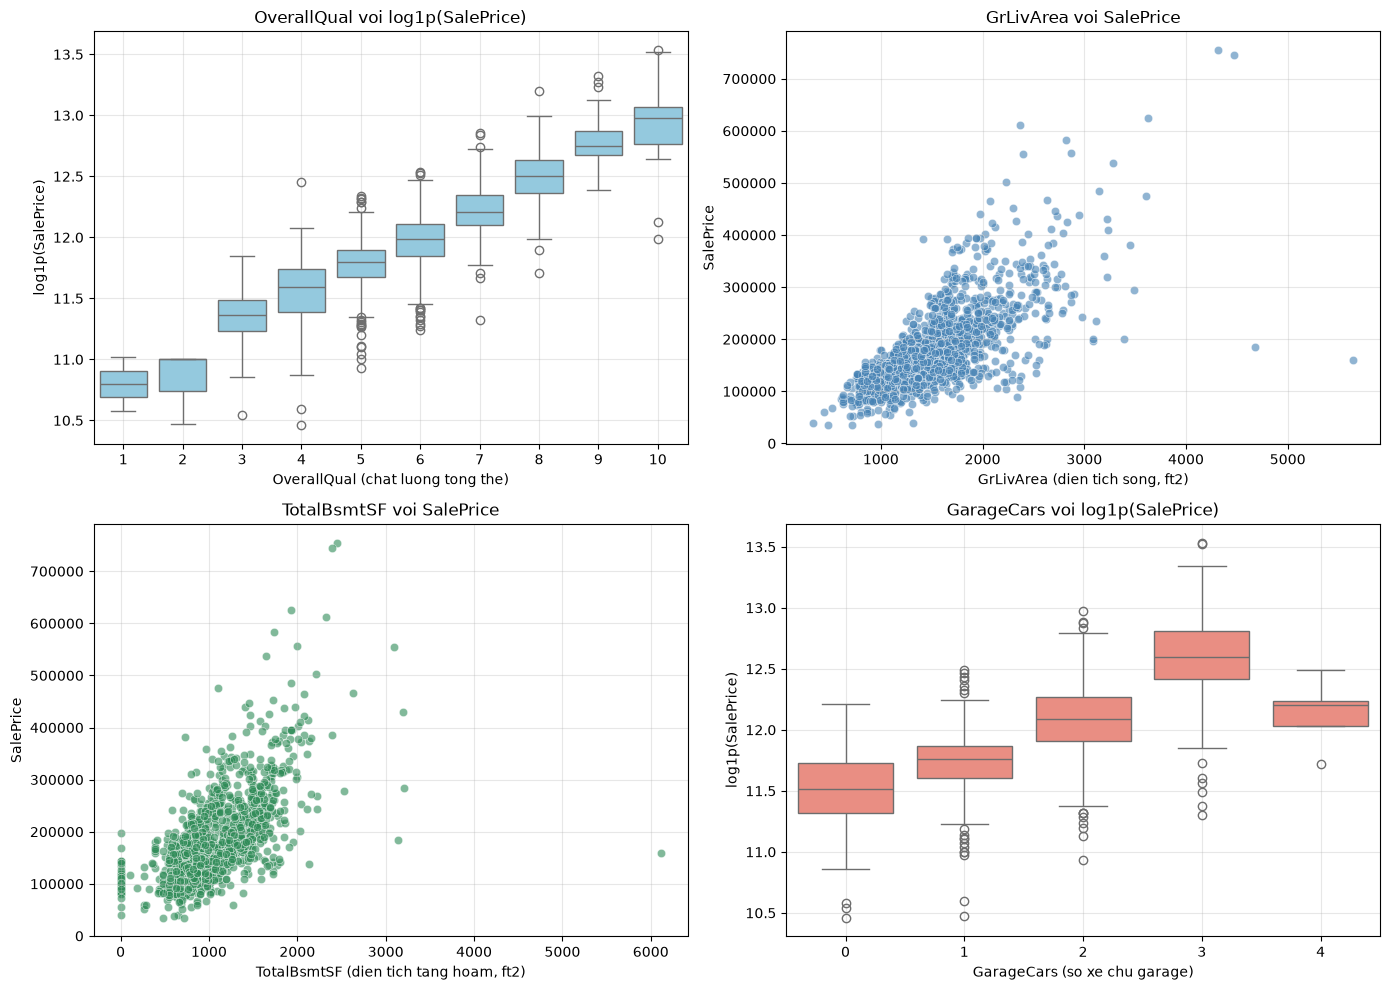

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x=train["OverallQual"], y=log_price, ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("OverallQual voi log1p(SalePrice)")
axes[0, 0].set_xlabel("OverallQual (chat luong tong the)")
axes[0, 0].set_ylabel("log1p(SalePrice)")

sns.scatterplot(data=train, x="GrLivArea", y="SalePrice", ax=axes[0, 1], alpha=0.6, color="steelblue")
axes[0, 1].set_title("GrLivArea voi SalePrice")
axes[0, 1].set_xlabel("GrLivArea (dien tich song, ft2)")
axes[0, 1].set_ylabel("SalePrice")

sns.scatterplot(data=train, x="TotalBsmtSF", y="SalePrice", ax=axes[1, 0], alpha=0.6, color="seagreen")
axes[1, 0].set_title("TotalBsmtSF voi SalePrice")
axes[1, 0].set_xlabel("TotalBsmtSF (dien tich tang hoam, ft2)")
axes[1, 0].set_ylabel("SalePrice")

sns.boxplot(x=train["GarageCars"], y=log_price, ax=axes[1, 1], color="salmon")
axes[1, 1].set_title("GarageCars voi log1p(SalePrice)")
axes[1, 1].set_xlabel("GarageCars (so xe chu garage)")
axes[1, 1].set_ylabel("log1p(SalePrice)")

for ax in axes.flat:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "numeric_features_vs_saleprice.png", dpi=150)
plt.show()

### 6.4. Nam dac trung so theo thoi gian: YearBuilt

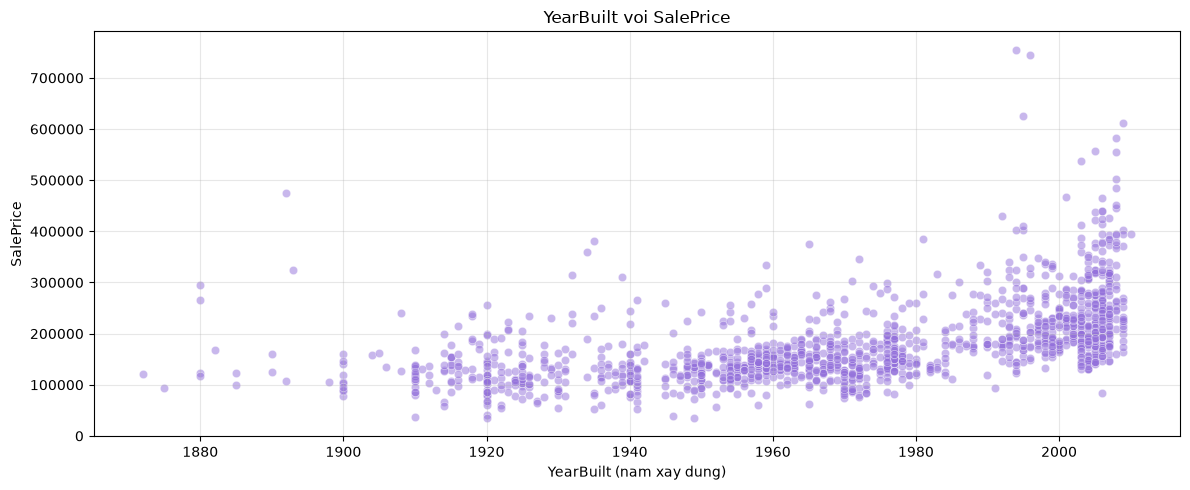

YearBuilt tu 1872 den 2010
Nha xay dung cang moi thi gia cang cao (tuong quan duong).


In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.scatterplot(data=train, x="YearBuilt", y="SalePrice", ax=ax, alpha=0.5, color="mediumpurple")
ax.set_title("YearBuilt voi SalePrice")
ax.set_xlabel("YearBuilt (nam xay dung)")
ax.set_ylabel("SalePrice")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "yearbuilt_vs_saleprice.png", dpi=150)
plt.show()

print("YearBuilt tu", int(train["YearBuilt"].min()), "den", int(train["YearBuilt"].max()))
print("Nha xay dung cang moi thi gia cang cao (tuong quan duong).")

### 6.5. Heatmap tuong quan cac dac trung so chinh

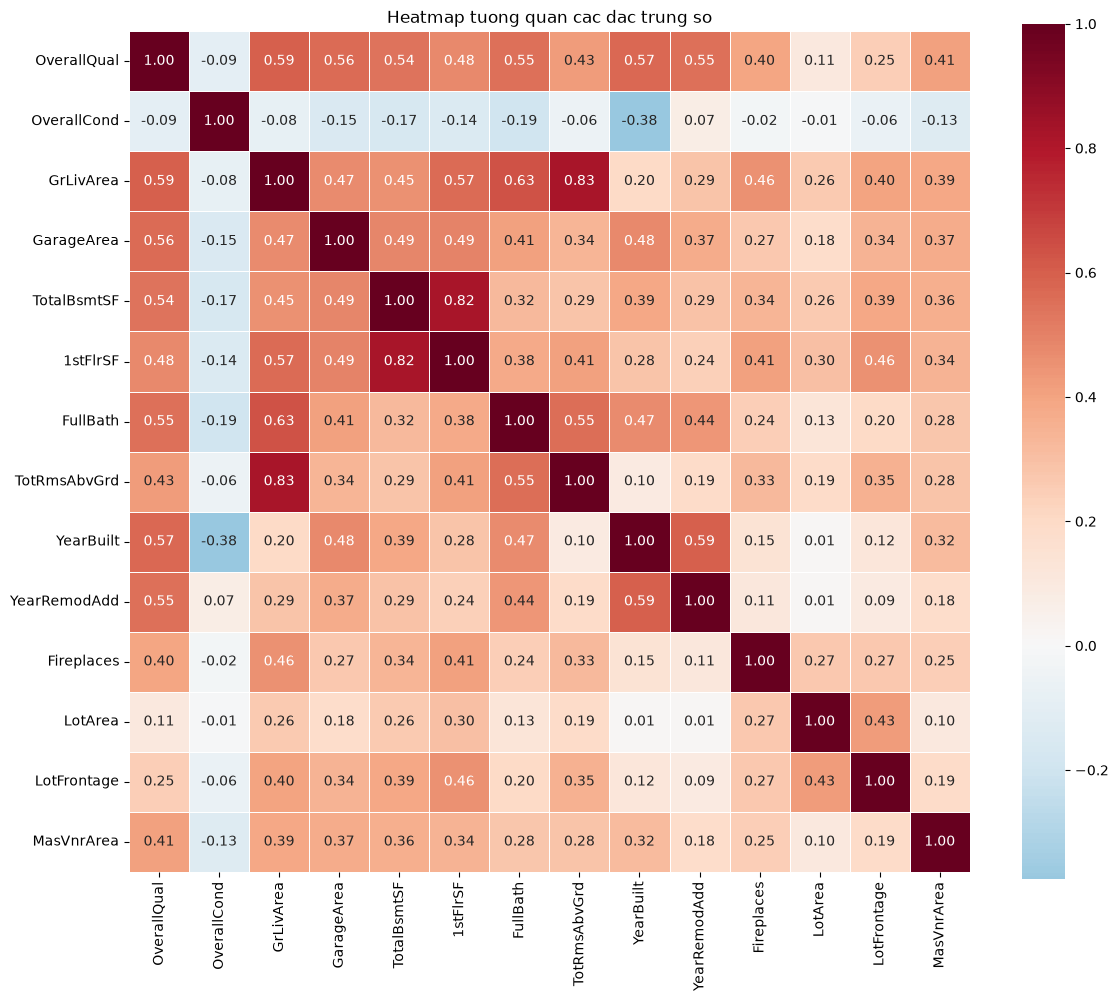

Nhan xet:
  - OverallQual va GrLivArea co tuong quan manh voi nhau.
  - GarageArea va GarageCars rat cao -> co the gay multicollinearity.


In [15]:
heatmap_cols = ["OverallQual", "OverallCond", "GrLivArea", "GarageArea",
                "TotalBsmtSF", "1stFlrSF", "FullBath", "TotRmsAbvGrd",
                "YearBuilt", "YearRemodAdd", "Fireplaces", "LotArea",
                "LotFrontage", "MasVnrArea"]

corr_matrix = train[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Heatmap tuong quan cac dac trung so")

plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_heatmap.png", dpi=150)
plt.show()

print("Nhan xet:")
print("  - OverallQual va GrLivArea co tuong quan manh voi nhau.")
print("  - GarageArea va GarageCars rat cao -> co the gay multicollinearity.")

### 6.6. Bieu do phan phoi cac dac trung so chinh

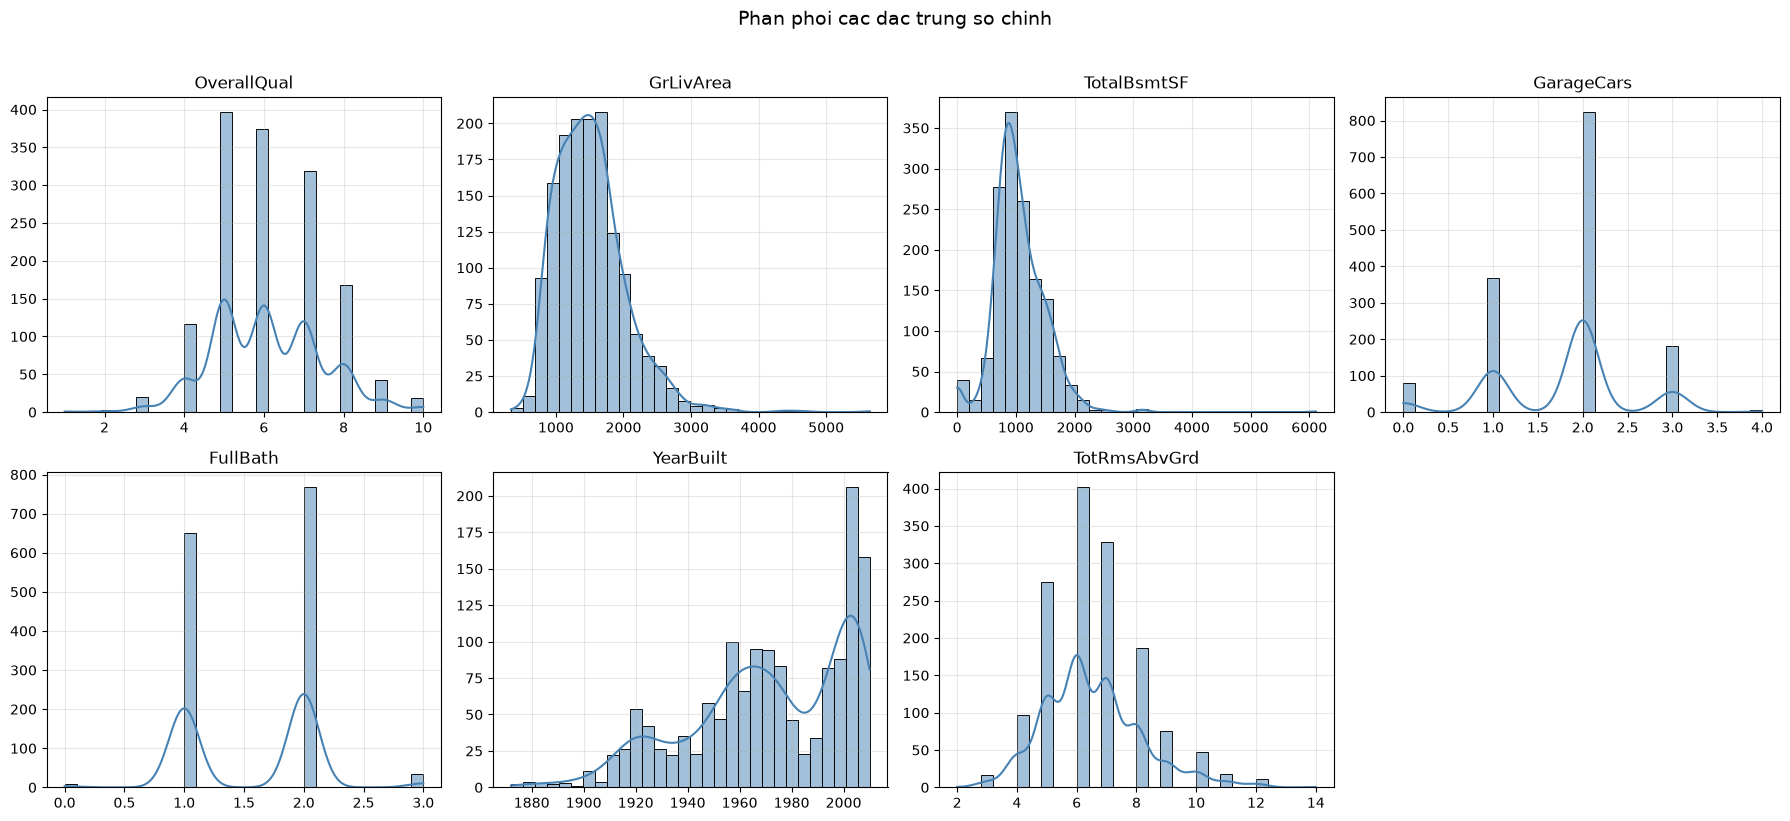

In [16]:
dist_cols = ["OverallQual", "GrLivArea", "TotalBsmtSF", "GarageCars",
              "FullBath", "YearBuilt", "TotRmsAbvGrd"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, dist_cols):
    sns.histplot(train[col], bins=30, kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(alpha=0.3)

axes[-1].axis("off")
plt.suptitle("Phan phoi cac dac trung so chinh", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "numeric_features_distribution.png", dpi=150)
plt.show()

## 7. Phan tich dac trung categorical

### 7.1. So luong gia tri khac nhau

In [17]:
cat_cols = train.select_dtypes(include=pp.STRING_DTYPES).columns.tolist()
print(f"So dac trung categorical: {len(cat_cols)}")

nunique = train[cat_cols].nunique().sort_values(ascending=False)
display(nunique.to_frame("so_gia_tri_khac_nhau"))

print("Nhan xet:")
print("  - Phan lon co it gia tri (2-5) -> OneHotEncoder xu ly hieu qua.")
print("  - Neighborhood 25 gia tri, Exterior2nd 16 gia tri -> van o muc do vua phai.")
print("  - Khong cot categorical nao co qua nhieu gia tri -> One-hot an toan.")

So dac trung categorical: 43


,so_gia_tri_khac_nhau
Neighborhood,25
Exterior2nd,16
Exterior1st,15
Condition1,9
SaleType,9
HouseStyle,8
RoofMatl,8
Condition2,8
Functional,7
BsmtFinType2,6


Nhan xet:
  - Phan lon co it gia tri (2-5) -> OneHotEncoder xu ly hieu qua.
  - Neighborhood 25 gia tri, Exterior2nd 16 gia tri -> van o muc do vua phai.
  - Khong cot categorical nao co qua nhieu gia tri -> One-hot an toan.


### 7.2. Top 10 gia tri pho bien cua cac categorical quan trong

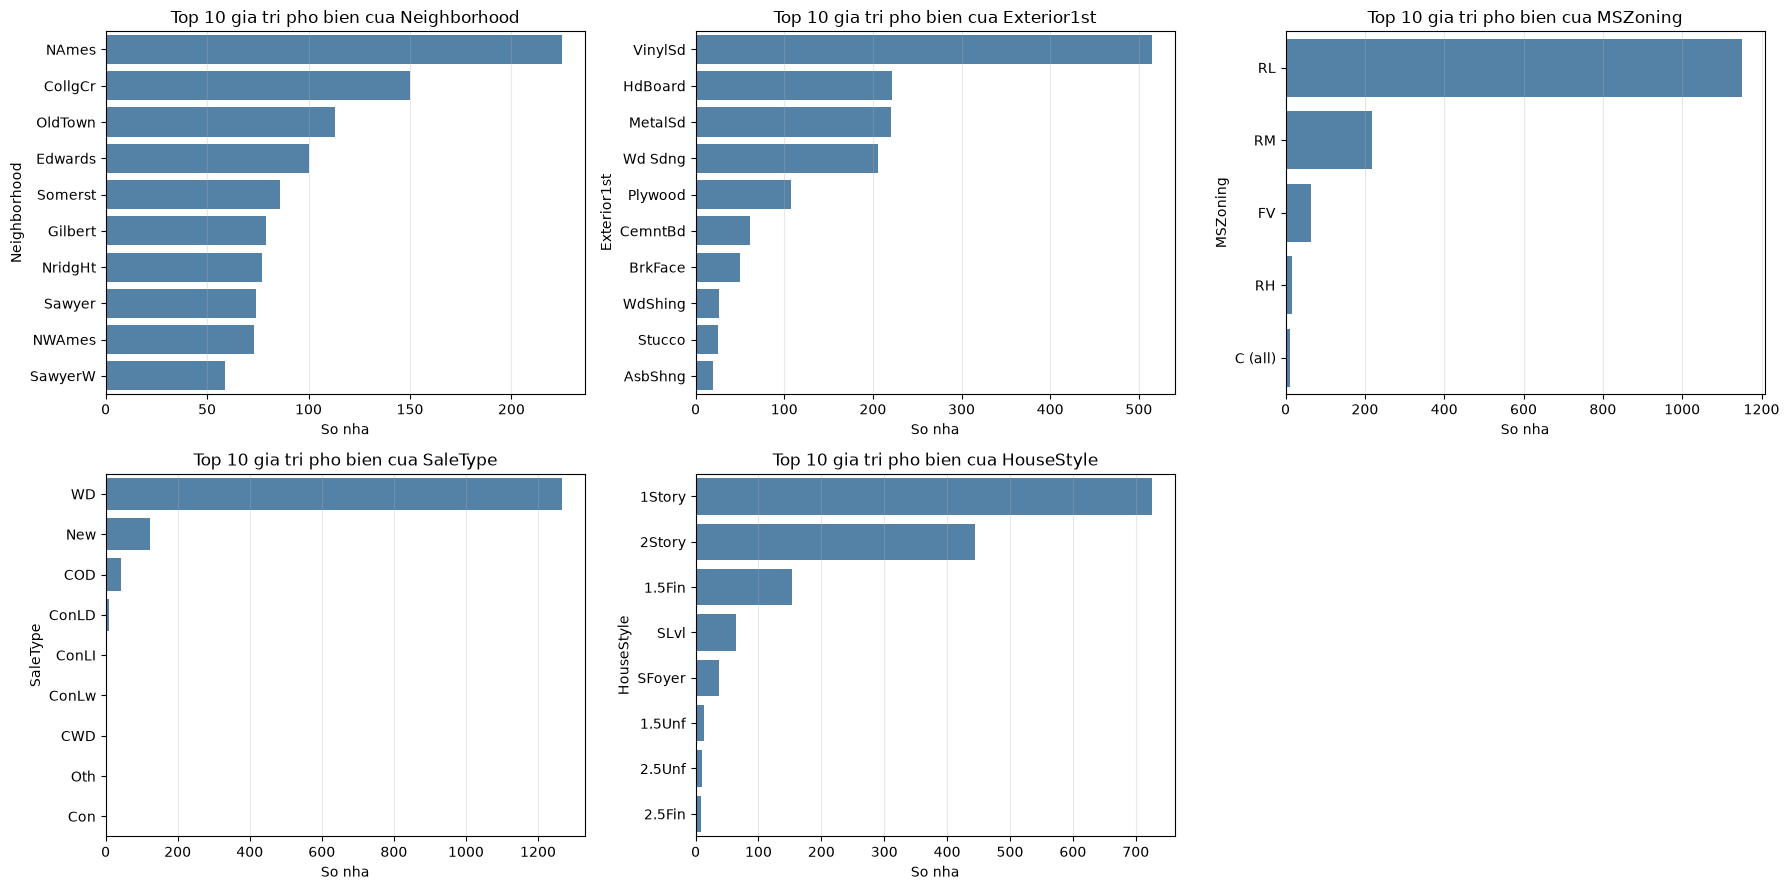

In [18]:
top_cats = ["Neighborhood", "Exterior1st", "MSZoning", "SaleType", "HouseStyle"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for ax, col in zip(axes, top_cats):
    counts = train[col].value_counts().head(10)
    sns.barplot(x=counts.values, y=counts.index, ax=ax, color="steelblue")
    ax.set_title(f"Top 10 gia tri pho bien cua {col}")
    ax.set_xlabel("So nha")
    ax.grid(alpha=0.3, axis="x")

axes[-1].axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "categorical_top_values.png", dpi=150)
plt.show()

### 7.3. Quan he giua categorical quan trong voi SalePrice

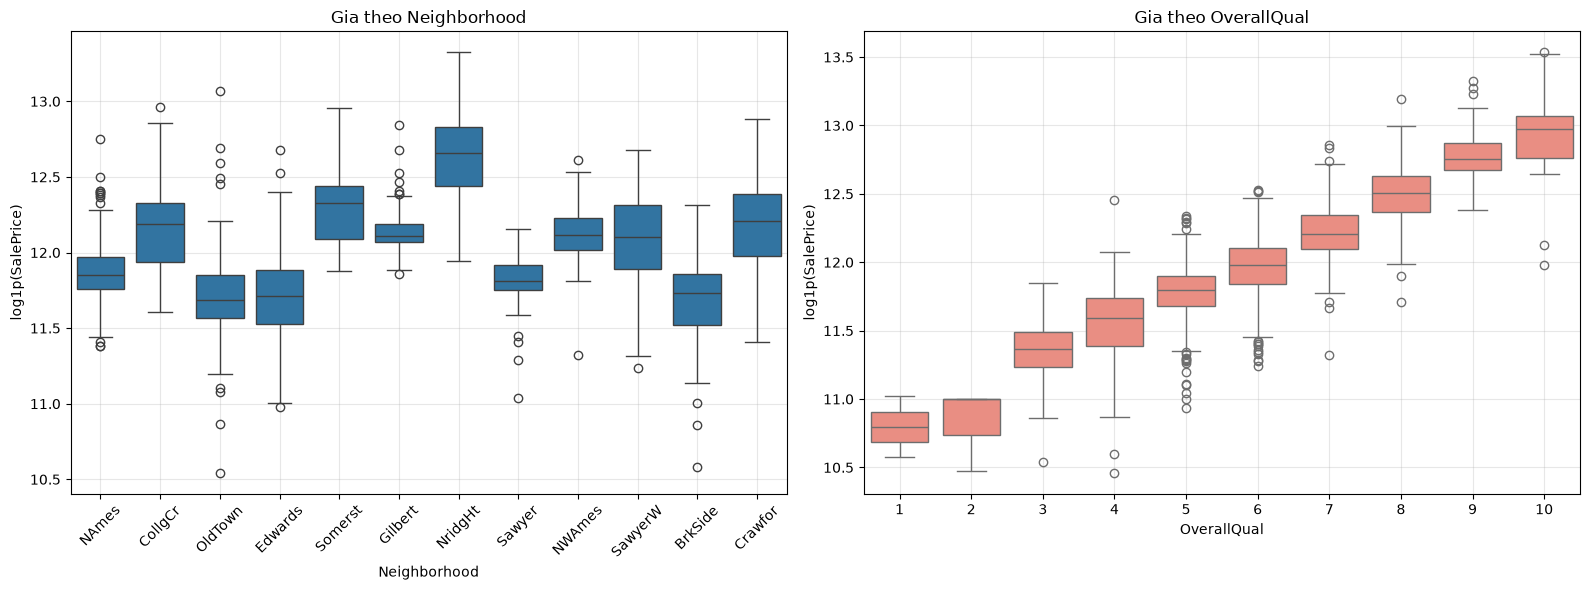

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=train, x="Neighborhood", y=log_price, ax=axes[0], order=train["Neighborhood"].value_counts().head(12).index)
axes[0].set_title("Gia theo Neighborhood")
axes[0].set_xlabel("Neighborhood")
axes[0].set_ylabel("log1p(SalePrice)")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=train, x="OverallQual", y=log_price, ax=axes[1], color="salmon")
axes[1].set_title("Gia theo OverallQual")
axes[1].set_xlabel("OverallQual")
axes[1].set_ylabel("log1p(SalePrice)")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "categorical_vs_saleprice.png", dpi=150)
plt.show()

## 8. Kiem tra outlier

### 8.1. Phat hien mau sai logic

Trong Ames Housing co mau dac bi chu quan: **nha co dien tich lon nhung gia re**. Mot nha 4000+ ft2 khong the re hon nhieu nha nho — mau nay sai logic.

In [20]:
outlier_mask = (train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)
outliers = train[outlier_mask]

print(f"So mau vi pham quy tac: {len(outliers)}")
display(outliers[["Id", "GrLivArea", "SalePrice", "OverallQual"]])
print()
print("Nhan xet:")
print(f"  - Chi {len(outliers)}/1460 mau ({len(outliers)/len(train)*100:.2f}%) — rat it.")
print("  - Dien tich lon nhung gia re bat thuong.")
print("  - QUYET DINH: giu nguyen du lieu, KHONG xoa mau nao.")
print("    Ly do: chi 2 mau, anh huong nho; xoa co the gay hao qua mau.")
print("    Thanh vien 4 co the thu thu nghiem loai bo neu thay can.")

So mau vi pham quy tac: 2


,Id,GrLivArea,SalePrice,OverallQual
523,524,4676,184750,10
1298,1299,5642,160000,10



Nhan xet:
  - Chi 2/1460 mau (0.14%) — rat it.
  - Dien tich lon nhung gia re bat thuong.
  - QUYET DINH: giu nguyen du lieu, KHONG xoa mau nao.
    Ly do: chi 2 mau, anh huong nho; xoa co the gay hao qua mau.
    Thanh vien 4 co the thu thu nghiem loai bo neu thay can.


In [21]:
print("=== So outlier theo quy tac IQR (1.5 x IQR) tren cac cot chinh ===")

iqr_cols = ["GrLivArea", "LotArea", "TotalBsmtSF", "1stFlrSF", "GarageArea", "SalePrice"]
for col in iqr_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((train[col] < lower) | (train[col] > upper)).sum()
    print(f"  {col:15s}: {n_out:5d} mau ({n_out/len(train)*100:5.1f}%)")

print()
print("Nhan xet:")
print("  - Rat nhieu gia tri outlier theo IQR, nhung phan lon la gia tri cao binh thuong")
print("    trong du lieu gia cao — khong phai loi du lieu.")
print("  - Vi vay KHONG xoa outlier theo IQR. Chi ghi nhan mau sai logic o 8.1.")

=== So outlier theo quy tac IQR (1.5 x IQR) tren cac cot chinh ===
  GrLivArea      :    31 mau (  2.1%)
  LotArea        :    69 mau (  4.7%)
  TotalBsmtSF    :    61 mau (  4.2%)
  1stFlrSF       :    20 mau (  1.4%)
  GarageArea     :    21 mau (  1.4%)
  SalePrice      :    61 mau (  4.2%)

Nhan xet:
  - Rat nhieu gia tri outlier theo IQR, nhung phan lon la gia tri cao binh thuong
    trong du lieu gia cao — khong phai loi du lieu.
  - Vi vay KHONG xoa outlier theo IQR. Chi ghi nhan mau sai logic o 8.1.


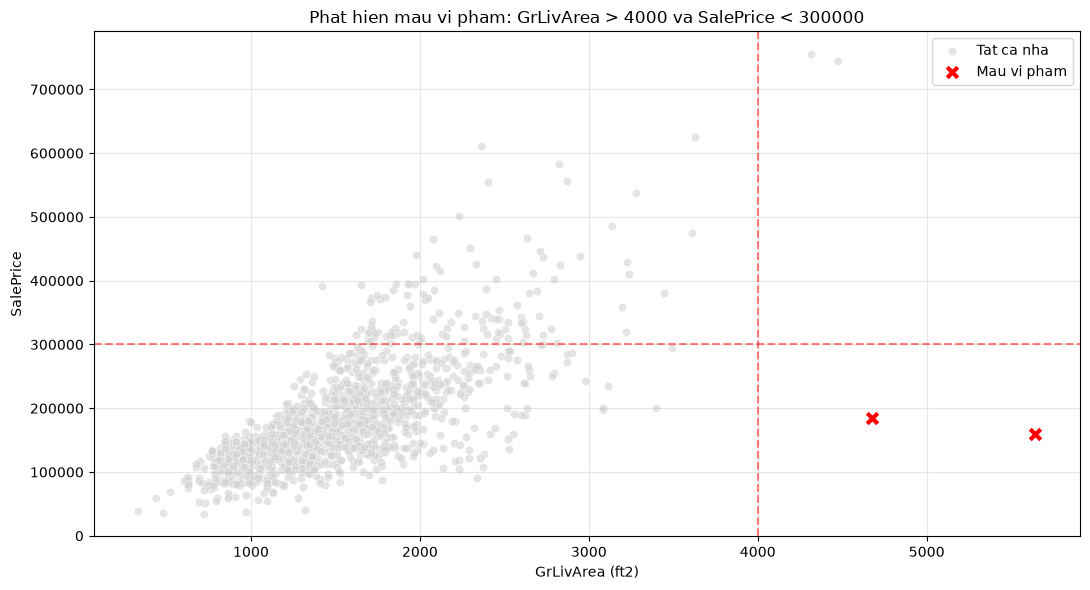

In [22]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.scatterplot(data=train, x="GrLivArea", y="SalePrice", ax=ax, alpha=0.6, color="lightgray", label="Tat ca nha")
sns.scatterplot(data=outliers, x="GrLivArea", y="SalePrice", ax=ax, color="red", s=120, marker="X", label="Mau vi pham")

ax.axvline(4000, color="red", linestyle="--", alpha=0.5)
ax.axhline(300000, color="red", linestyle="--", alpha=0.5)
ax.set_title("Phat hien mau vi pham: GrLivArea > 4000 va SalePrice < 300000")
ax.set_xlabel("GrLivArea (ft2)")
ax.set_ylabel("SalePrice")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "outlier_detection.png", dpi=150)
plt.show()

## 9. Kiem tra du lieu trung lap

### 9.1. Trung lap (duplicates)

In [23]:
print("So dong trung lap Id:", train["Id"].duplicated().sum())
print("So dong trung lap dac trung (bo Id, SalePrice):",
      train.drop(columns=["Id", pp.TARGET_COLUMN]).duplicated().sum())

print("=== Trung lap Id giua train va test ===")
overlap = set(train["Id"]) & set(test["Id"])
print(f"So Id bi trung: {len(overlap)}")

print("Nhan xet: khong co dong trung lap, train va test doc lap nhau.")

So dong trung lap Id: 0
So dong trung lap dac trung (bo Id, SalePrice): 0
=== Trung lap Id giua train va test ===
So Id bi trung: 0
Nhan xet: khong co dong trung lap, train va test doc lap nhau.


### 9.2. Kiem tra gia tri rong

Trong du lieu nay khong co chuoi rong. Tat ca gia tri thieu deu la NaN that su, nen `SimpleImputer` xu ly NaN la du.

In [24]:
empty_count = sum((train[col].astype(str).str.strip() == "").sum() for col in object_cols)

print(f"So o rong chuoi trong cot categorical: {empty_count}")
print("-> Khong co chuoi rong -> SimpleImputer xu ly NaN la du.")

So o rong chuoi trong cot categorical: 0
-> Khong co chuoi rong -> SimpleImputer xu ly NaN la du.


## 10. Xay dung preprocessing pipeline

Day la phan quan trong nhat de ban giao cho thieu vien 2 va 3.

### 10.1. Chia cot numeric / categorical

Mac dinh giu nguyen dtype goc cua Kaggle — `MSSubClass` van la int64.

In [25]:
X, y = pp.split_feature_target(pp.add_target_log(train))

numeric_cols, categorical_cols = pp.select_column_groups(X)

print(f"So dac trung numeric     : {len(numeric_cols)}")
print(f"So dac trung categorical : {len(categorical_cols)}")
print(f"Tong                     : {len(numeric_cols) + len(categorical_cols)}")
print(f"So cot trong X           : {X.shape[1]}")

assert len(numeric_cols) + len(categorical_cols) == X.shape[1], "Co cot bi bo qua!"

print()
print("Danh sach cot NUMERIC:")
print(numeric_cols)

print()
print("Danh sach cot CATEGORICAL:")
print(categorical_cols)

So dac trung numeric     : 36
So dac trung categorical : 43
Tong                     : 79
So cot trong X           : 79

Danh sach cot NUMERIC:
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Danh sach cot CATEGORICAL:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinTy

### 10.2. Tao va kiem tra pipeline

- **Numeric:** `SimpleImputer(median)` → `StandardScaler`.
- **Categorical:** `SimpleImputer(most_frequent)` → `OneHotEncoder(handle_unknown="ignore")`.
- **`handle_unknown="ignore"`:** transform duoc tap test chua category chua tung xuat hien.

> Pipeline phai `fit` tren tap train roi moi `transform` validation/test. KHONG duoc fit tren toan bo du lieu truoc khi chia tap.

In [26]:
preprocessor = pp.build_preprocessor(numeric_cols, categorical_cols)

print("Cau truc pipeline:")
display(preprocessor)

Cau truc pipeline:


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [27]:
from scipy import sparse

X_processed = preprocessor.fit_transform(X)

print("Hinh dang sau khi tien xu ly:", X_processed.shape)
print(f"So cot sau one-hot      : {X_processed.shape[1]}")
print(f"So cot goc              : {X.shape[1]}")

if sparse.issparse(X_processed):
    density = X_processed.nnz / (X_processed.shape[0] * X_processed.shape[1]) * 100
    print(f"Kieu du lieu           : sparse (CSR), mat do {density:.1f}%")
    print(f"So gia tri NaN con lai : {int(np.isnan(X_processed.data).sum())}")
else:
    print(f"Kieu du lieu           : dense (ndarray)")
    print(f"So gia tri NaN con lai : {int(np.isnan(X_processed).sum())}")

print()
print("Nhan xet:")
print(f"  - 43 cot categorical -> {X_processed.shape[1]} cot sau one-hot.")
print(f"  - Ma tran dense chi ~{X.shape[0] * X_processed.shape[1] * 8 / 1e6:.1f} MB -> rat nhe.")

Hinh dang sau khi tien xu ly: (1460, 287)
So cot sau one-hot      : 287
So cot goc              : 79
Kieu du lieu           : sparse (CSR), mat do 27.5%
So gia tri NaN con lai : 0

Nhan xet:
  - 43 cot categorical -> 287 cot sau one-hot.
  - Ma tran dense chi ~3.4 MB -> rat nhe.


### 10.3. Kiem tra khong ro ri thong tin (data leakage)

**Cach kiem tra:** chi fit pipeline tren mot tap con roi transform tap con. So cot one-hot phai **it hon** ban full-data, vi tap con it du lieu hon. Neu bang het → dang ro ri thong tin.

In [28]:
from sklearn.model_selection import train_test_split

X_sub, _ = train_test_split(X, test_size=0.2, random_state=RANDOM_STATE)

pre_sub = pp.build_preprocessor(numeric_cols, categorical_cols)
pre_sub.fit(X_sub)                            # chi fit tren tap con
X_sub_processed = pre_sub.transform(X_sub)   # transform, khong fit lai

n_cat_sub = X_sub_processed.shape[1] - len(numeric_cols)
n_cat_full = X_processed.shape[1] - len(numeric_cols)

print(f"Tap con   : {n_cat_sub} cot one-hot")
print(f"Toan bo   : {n_cat_full} cot one-hot")
print()
if n_cat_sub < n_cat_full:
    print("-> Tap con it category hon. DUNG: khong ro ri thong tin.")
else:
    print("-> Canh bao: co the dang ro ri thong tin.")

Tap con   : 249 cot one-hot
Toan bo   : 251 cot one-hot

-> Tap con it category hon. DUNG: khong ro ri thong tin.


### 10.4. Bien the dense cho mo hinh khong ho tro sparse

`HistGradientBoostingRegressor` va PyTorch **khong** nhan ma tran sparse. Dung `sparse_threshold=0` de ep pipeline tra ve ma tran dense.

In [29]:
preprocessor_dense = pp.build_preprocessor(numeric_cols, categorical_cols, sparse_threshold=0)
X_dense = preprocessor_dense.fit_transform(X)

print("Kieu du lieu voi sparse_threshold=0:", type(X_dense).__name__)
print("Hinh dang:", X_dense.shape)
print(f"Kich thuoc dense: {X_dense.nbytes / 1e6:.1f} MB")

if sparse.issparse(X_processed):
    print(f"Gia tri sparse va dense giong het: {np.allclose(X_processed.toarray(), X_dense)}")

print()
print("Huong dan cho ca nhom:")
print("  - Ridge / Lasso / RandomForest: dung ban sparse (mac dinh) — tiet kiem RAM.")
print("  - HistGradientBoosting / MLP PyTorch: dung ban dense (sparse_threshold=0).")

Kieu du lieu voi sparse_threshold=0: ndarray
Hinh dang: (1460, 287)
Kich thuoc dense: 3.4 MB
Gia tri sparse va dense giong het: True

Huong dan cho ca nhom:
  - Ridge / Lasso / RandomForest: dung ban sparse (mac dinh) — tiet kiem RAM.
  - HistGradientBoosting / MLP PyTorch: dung ban dense (sparse_threshold=0).


## 11. Ghi chu ky thuat: cot `MSSubClass`

`MSSubClass` la **ma loai nha** (20, 30, 60, 120, ...), khong phai so do. Dien gia 120 > 60 khong co y nghia nha 120 'lon hon' nha 60 — chi la ma khac nhau.

### Quyet dinh: GIU NGUYEN dtype goc o baseline

Ly do:

1. De **chay tren du lieu goc truoc** xem ket qua ra sao — cach nguoi hoc thuong lam: tao baseline tu duyen, roi thay vung cai tien.
2. Khong nen sua du lieu khi chua biet no co giup hay khong.
3. Thanh vien 4 se chay **ablation E0–E5** de kiem chung.

**Neu can thu nghiem:** goi `select_column_groups(X, cast_mssubclass=True)` de chuyen `MSSubClass` sang categorical.

In [30]:
numeric_orig, categorical_orig = pp.select_column_groups(X, cast_mssubclass=False)
numeric_cast, categorical_cast = pp.select_column_groups(X, cast_mssubclass=True)

print("=== Goc (MSSubClass la numeric) ===")
print(f"  numeric     : {len(numeric_orig)}")
print(f"  categorical : {len(categorical_orig)}")

print("=== Ep MSSubClass thanh categorical ===")
print(f"  numeric     : {len(numeric_cast)}")
print(f"  categorical : {len(categorical_cast)}")

print()
print("Nhan xet:")
print("  - Ep thanh categorical se them ~15 cot one-hot.")
print("  - Chua ket luan duoc gi se tot hon — can chay thu nghiem so sanh.")

print("Gia tri cua MSSubClass:", sorted(train["MSSubClass"].unique()))

=== Goc (MSSubClass la numeric) ===
  numeric     : 36
  categorical : 43
=== Ep MSSubClass thanh categorical ===
  numeric     : 35
  categorical : 44

Nhan xet:
  - Ep thanh categorical se them ~15 cot one-hot.
  - Chua ket luan duoc gi se tot hon — can chay thu nghiem so sanh.
Gia tri cua MSSubClass: [np.int64(20), np.int64(30), np.int64(40), np.int64(45), np.int64(50), np.int64(60), np.int64(70), np.int64(75), np.int64(80), np.int64(85), np.int64(90), np.int64(120), np.int64(160), np.int64(180), np.int64(190)]


## 12. Ban giao cho ca nhom

### 12.1. Ket qua EDA

| Noi dung | Ket qua |
|---|---|
| So mau train / test | 1460 / 1459 |
| So cot train / test | 81 / 80 |
| Dac trung numeric | 36 cot (bo `Id`) |
| Dac trung categorical | 43 cot |
| Cot bi thieu du lieu | 19 cot, 7829 o (6.5%) |
| Skewness `SalePrice` | 1.88 (lech phai manh) |
| Skewness `log1p(SalePrice)` | 0.12 (gan doi xung) |
| Dac trung manh nhat | `OverallQual` (0.82), `GrLivArea` (0.70), `GarageCars` (0.68) |
| Outlier sai logic | 2 mau — giu nguyen |
| Dong trung lap | 0 |

### 12.2. Module dung chung

`src/preprocessing.py` cung cap:

- `load_data()` — doc `train.csv`, `test.csv`.
- `add_target_log()` — them cot `log1p(SalePrice)`.
- `split_feature_target()` — tach X va y.
- `select_column_groups()` — chia cot numeric / categorical.
- `build_preprocessor()` — tao pipeline xu ly missing + encode.
- `prepare_features()` — tien xu ly nhanh (chi de kham pha, khong dung khi CV).

### 12.3. Cach dung trong model cua thieu vien 2 va 3

```python
import sys; sys.path.insert(0, 'src')
import preprocessing as pp
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

train, test = pp.load_data()
X, y = pp.split_feature_target(pp.add_target_log(train))
num_cols, cat_cols = pp.select_column_groups(X)

model = Pipeline([
    ('preprocessor', pp.build_preprocessor(num_cols, cat_cols)),
    ('regressor', Ridge(alpha=10.0))
])
```

> **Khong dung `prepare_features()` khi cross-validation** — ham nay fit tren toan bo du lieu se gay ro ri thong tin. Hay dat `build_preprocessor` vao trong `Pipeline`.

### 12.4. Danh sach bieu do da luu

| File | Noi dung |
|---|---|
| `saleprice_distribution.png` | Phan phoi SalePrice va log1p(SalePrice) |
| `numeric_features_vs_saleprice.png` | OverallQual, GrLivArea, TotalBsmtSF, GarageCars |
| `yearbuilt_vs_saleprice.png` | YearBuilt voi SalePrice |
| `correlation_heatmap.png` | Heatmap tuong quan dac trung so |
| `numeric_features_distribution.png` | Phan phoi cac dac trung so chinh |
| `categorical_top_values.png` | Top 10 gia tri pho bien categorical |
| `categorical_vs_saleprice.png` | Neighborhood, OverallQual voi gia |
| `outlier_detection.png` | Phat hien mau vi pham |

In [31]:
print("Cac bieu do da luu vao:")
print(FIG_DIR)
print()
for f in sorted(FIG_DIR.glob("*.png")):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.0f} KB)")

Cac bieu do da luu vao:
/home/hungmg/Documents/python/GROUP_DEEEP_LEARNING_HK1_2026/TUAN03/lab03_house_price/outputs/figures

  categorical_top_values.png  (162 KB)
  categorical_vs_saleprice.png  (117 KB)
  correlation_heatmap.png  (315 KB)
  numeric_features_distribution.png  (215 KB)
  numeric_features_vs_saleprice.png  (362 KB)
  outlier_detection.png  (132 KB)
  saleprice_distribution.png  (56 KB)
  yearbuilt_vs_saleprice.png  (158 KB)
